In [1]:
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
import pandas as pd


In [2]:
iris=load_iris()
X=iris.data
y=iris.target

In [3]:
X.shape

(150, 4)

<Axes: >

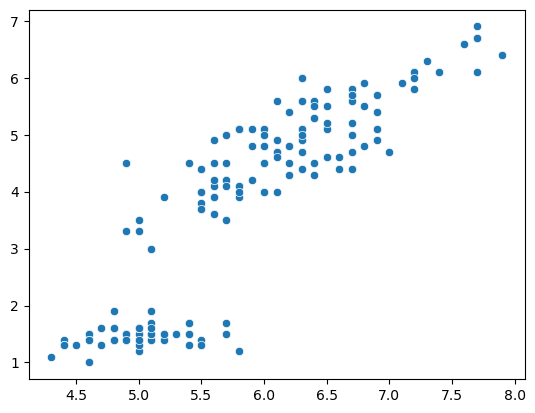

In [4]:
#visalization

# sns.scatterplot(x=X[:,0],y=X[:,2],c=y)
sns.scatterplot(x=X[:,0],y=X[:,2])

In [5]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X_scaler=scaler.fit_transform(X)

In [6]:
# dimention reduction
from sklearn.decomposition import PCA
pca=PCA(n_components=2)

pca_data=pca.fit_transform(X_scaler)

In [7]:
# find the wcss values

wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit(pca_data)
    wcss.append(kmeans.inertia_)


<Axes: >

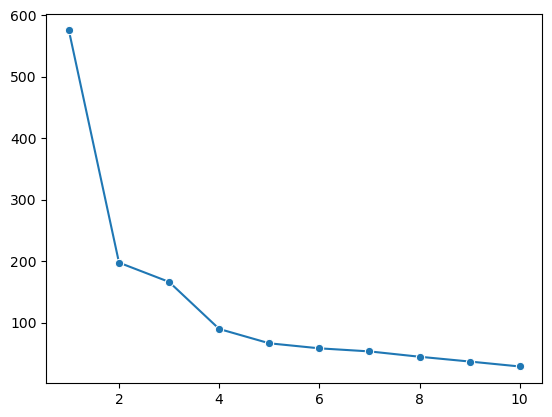

In [8]:
sns.lineplot(x=range(1,11),y=wcss,marker='o')

# model train and predict visualization

<Axes: >

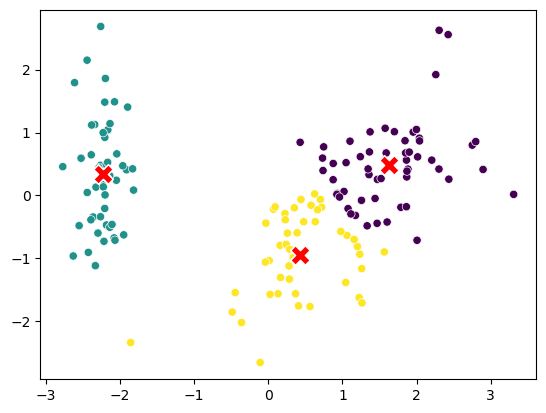

In [9]:
kmeans=KMeans(n_clusters=3,random_state=10)
label=kmeans.fit_predict(pca_data)

sns.scatterplot(x=pca_data[:,0],y=pca_data[:,1],c=label)
sns.scatterplot(x=kmeans.cluster_centers_[:,0],y=kmeans.cluster_centers_[:,1],marker="X",c="red",s=200)

# Real data visualization

<Axes: >

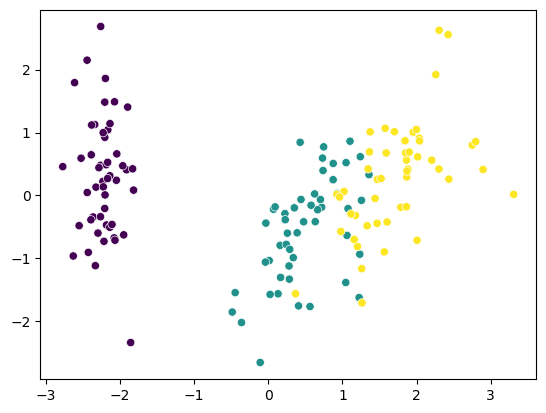

In [10]:
sns.scatterplot(x=pca_data[:,0],y=pca_data[:,1],c=y)
